#### Importing necessary libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

#### Unzipping and Loading Dataset

In [4]:
# To unzip and load the zipped dataset
import zipfile
import os

# Specify the path to the zip file and the directory to extract it to
zip_file_path = "C:/Users/User/Downloads/archive (1).zip"
extract_to = "C:/Users/User/Desktop/PCOS Dataset"

# Ensure the extraction directory exists
os.makedirs(extract_to, exist_ok=True)

# Open and extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # List all files in the zip
    print("Files in the zip:", zip_ref.namelist())
    # Extract all files
    zip_ref.extractall(extract_to)

print(f"Files have been extracted to: {extract_to}")

Files in the zip: ['pcos_prediction_dataset.csv']
Files have been extracted to: C:/Users/User/Desktop/PCOS Dataset


In [5]:
file = pd.read_csv("C:/Users/User\/Desktop/PCOS Dataset/pcos_prediction_dataset.csv")

In [6]:
# Making a copy of the file for reproducibility and avoid changes to origina"C:\Users\User\Desktop\PCOS Dataset\pcos_prediction_dataset.csv"l dataset
df = file.copy()

##### Overview of Dataset

In [8]:
# Viewing the first few rows of the dataset
df.head()

,Country,Age,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Lifestyle Score,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Undiagnosed PCOS Likelihood,Ethnicity,Diagnosis
0,Madagascar,26,Overweight,Regular,Yes,Severe,Yes,Yes,2,Low,Rural,High,Yes,No,0.107938,Hispanic,Yes
1,Vietnam,16,Underweight,Regular,Yes,NaN,No,Yes,4,High,Rural,Middle,Yes,No,0.156729,Other,No
2,Somalia,41,Normal,Regular,No,Moderate,No,No,7,Medium,Urban,Middle,Yes,Yes,0.202901,Other,No
3,Malawi,27,Normal,Irregular,No,Mild,No,No,10,Low,Urban,High,Yes,No,0.073926,Caucasian,Yes
4,France,26,Overweight,Irregular,Yes,NaN,No,No,7,Medium,Urban,Middle,No,No,0.229266,Caucasian,No


In [9]:
# Viewing the last rows of dataset
df.tail()

,Country,Age,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Lifestyle Score,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Undiagnosed PCOS Likelihood,Ethnicity,Diagnosis
119995,Guinea,28,Normal,Regular,No,Moderate,Yes,No,3,Low,Urban,Middle,Yes,Yes,0.090663,African,No
119996,Mozambique,35,Overweight,Regular,No,NaN,No,No,5,Low,Rural,High,Yes,Yes,0.167482,Asian,No
119997,Cambodia,16,Normal,Regular,No,Moderate,No,No,9,Medium,Rural,Low,Yes,Yes,0.236241,African,Yes
119998,Benin,15,Obese,Regular,Yes,NaN,Yes,Yes,1,Medium,Rural,High,No,No,0.119993,Hispanic,No
119999,Brazil,17,Obese,Irregular,Yes,NaN,No,No,6,Medium,Rural,Low,Yes,No,0.223073,Asian,No


In [10]:
# Understanding the shape of the dataset
df.shape

(120000, 17)

In [11]:
# Checking the data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      120000 non-null  object 
 1   Age                          120000 non-null  int64  
 2   BMI                          120000 non-null  object 
 3   Menstrual Regularity         120000 non-null  object 
 4   Hirsutism                    120000 non-null  object 
 5   Acne Severity                59915 non-null   object 
 6   Family History of PCOS       120000 non-null  object 
 7   Insulin Resistance           120000 non-null  object 
 8   Lifestyle Score              120000 non-null  int64  
 9   Stress Levels                120000 non-null  object 
 10  Urban/Rural                  120000 non-null  object 
 11  Socioeconomic Status         120000 non-null  object 
 12  Awareness of PCOS            120000 non-null  object 
 13 

In [12]:
df.duplicated().sum()

0

In [13]:
df.describe()

,Age,Lifestyle Score,Undiagnosed PCOS Likelihood
count,120000.000000,120000.000000,120000.000000
mean,31.980508,5.506567,0.149937
std,10.096799,2.871052,0.057786
min,15.000000,1.000000,0.050001
25%,23.000000,3.000000,0.099820
50%,32.000000,6.000000,0.149844
75%,41.000000,8.000000,0.200061
max,49.000000,10.000000,0.249998


In [14]:
# Making a list of all categorical variables
cat_col = list(df.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(df[column].value_counts())
    print("-" * 50)

Country
Burkina Faso      1667
Malawi            1632
Ghana             1629
Vietnam           1626
South Korea       1626
South Africa      1619
France            1609
Chile             1609
Peru              1608
Philippines       1607
Canada            1602
Ethiopia          1598
Spain             1598
Indonesia         1596
Yemen             1593
Senegal           1592
Kenya             1591
India             1590
Argentina         1587
Colombia          1583
Pakistan          1581
Madagascar        1581
Russia            1577
Italy             1574
United States     1574
Ecuador           1572
Germany           1571
Iran              1570
Mexico            1570
Mali              1570
Brazil            1569
Romania           1567
Afghanistan       1566
Burundi           1565
Morocco           1565
Rwanda            1563
Kazakhstan        1562
Thailand          1560
Ukraine           1560
Ivory Coast       1560
Japan             1560
Myanmar           1559
China             1554
Ang

In [15]:
# Checking the number of unique values in the variable 'Acne Severity'
df["Acne Severity"].nunique() 

3

In [16]:
# Identifying number of missing values
print(df.isnull().sum())

Country                            0
Age                                0
BMI                                0
Menstrual Regularity               0
Hirsutism                          0
Acne Severity                  60085
Family History of PCOS             0
Insulin Resistance                 0
Lifestyle Score                    0
Stress Levels                      0
Urban/Rural                        0
Socioeconomic Status               0
Awareness of PCOS                  0
Fertility Concerns                 0
Undiagnosed PCOS Likelihood        0
Ethnicity                          0
Diagnosis                          0
dtype: int64


In [17]:
print(df['Acne Severity'].nunique())

3


In [18]:
df['Acne Severity'] = df['Acne Severity'].fillna("None")

In [19]:
df.head()

,Country,Age,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Lifestyle Score,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Undiagnosed PCOS Likelihood,Ethnicity,Diagnosis
0,Madagascar,26,Overweight,Regular,Yes,Severe,Yes,Yes,2,Low,Rural,High,Yes,No,0.107938,Hispanic,Yes
1,Vietnam,16,Underweight,Regular,Yes,None,No,Yes,4,High,Rural,Middle,Yes,No,0.156729,Other,No
2,Somalia,41,Normal,Regular,No,Moderate,No,No,7,Medium,Urban,Middle,Yes,Yes,0.202901,Other,No
3,Malawi,27,Normal,Irregular,No,Mild,No,No,10,Low,Urban,High,Yes,No,0.073926,Caucasian,Yes
4,France,26,Overweight,Irregular,Yes,None,No,No,7,Medium,Urban,Middle,No,No,0.229266,Caucasian,No


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      120000 non-null  object 
 1   Age                          120000 non-null  int64  
 2   BMI                          120000 non-null  object 
 3   Menstrual Regularity         120000 non-null  object 
 4   Hirsutism                    120000 non-null  object 
 5   Acne Severity                120000 non-null  object 
 6   Family History of PCOS       120000 non-null  object 
 7   Insulin Resistance           120000 non-null  object 
 8   Lifestyle Score              120000 non-null  int64  
 9   Stress Levels                120000 non-null  object 
 10  Urban/Rural                  120000 non-null  object 
 11  Socioeconomic Status         120000 non-null  object 
 12  Awareness of PCOS            120000 non-null  object 
 13 

#### Exploratory Data Analysis

##### Univariate Analysis

In [23]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

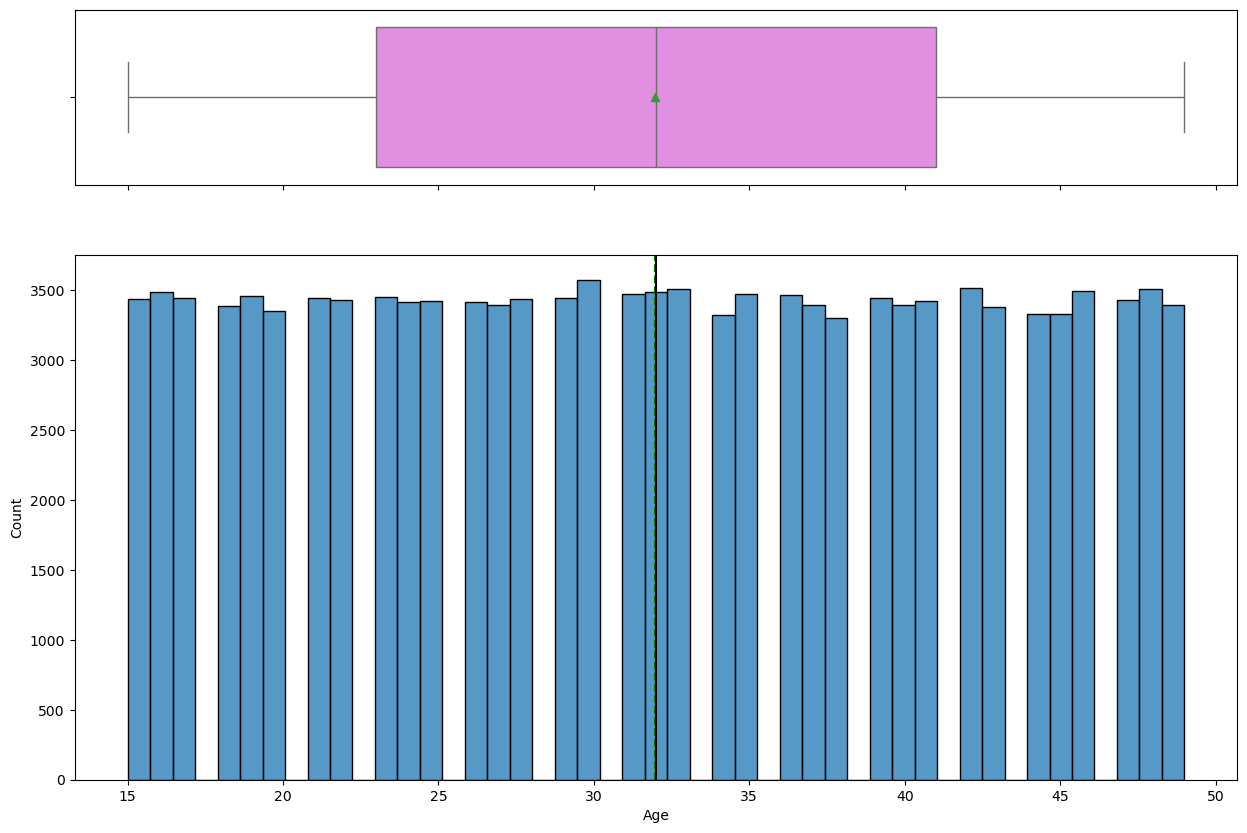

In [24]:
histogram_boxplot(df, 'Age')

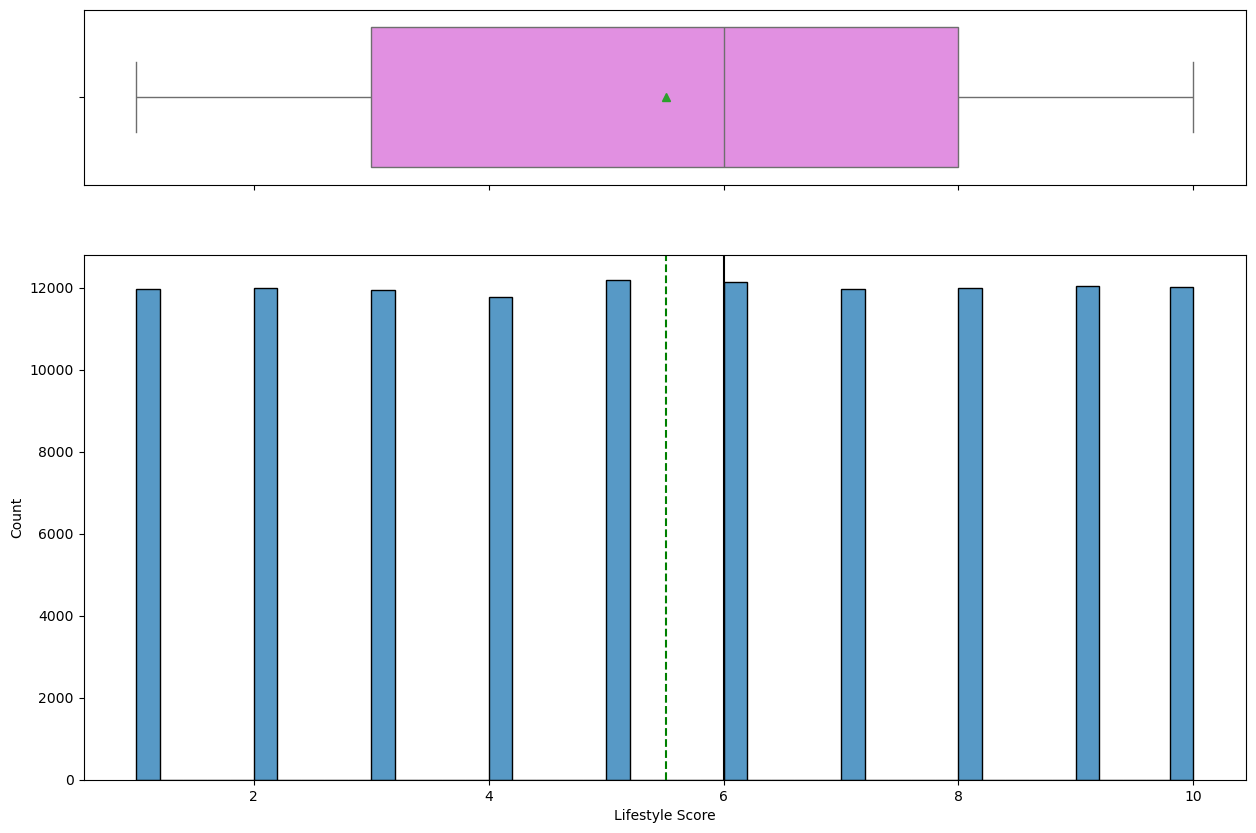

In [25]:
histogram_boxplot(df, 'Lifestyle Score')

In [26]:
# Function to view labelled barplots of all categorical variable
def plot_categorical_variables(data, exclude_column=None):
    # Identify categorical columns
    categorical_cols = data.select_dtypes(include=['object', 'category']).columns
    
    # Remove the excluded column if specified
    if exclude_column in categorical_cols:
        categorical_cols = categorical_cols.drop(exclude_column)
    
    # Set up the matplotlib figure
    num_vars = len(categorical_cols)
    fig, axes = plt.subplots(nrows=(num_vars // 3) + 1, ncols=3, figsize=(15, 5 * ((num_vars // 3) + 1)))
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    for i, col in enumerate(categorical_cols):
        # Create a count plot for each categorical variable
        sns.countplot(data=data, x=col, ax=axes[i])
        
        # Calculate percentages
        total = len(data[col])
        for p in axes[i].patches:
            percentage = f'{100 * p.get_height() / total:.1f}%'
            axes[i].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='bottom', fontsize=10)

        axes[i].set_title(f'Count of {col}')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

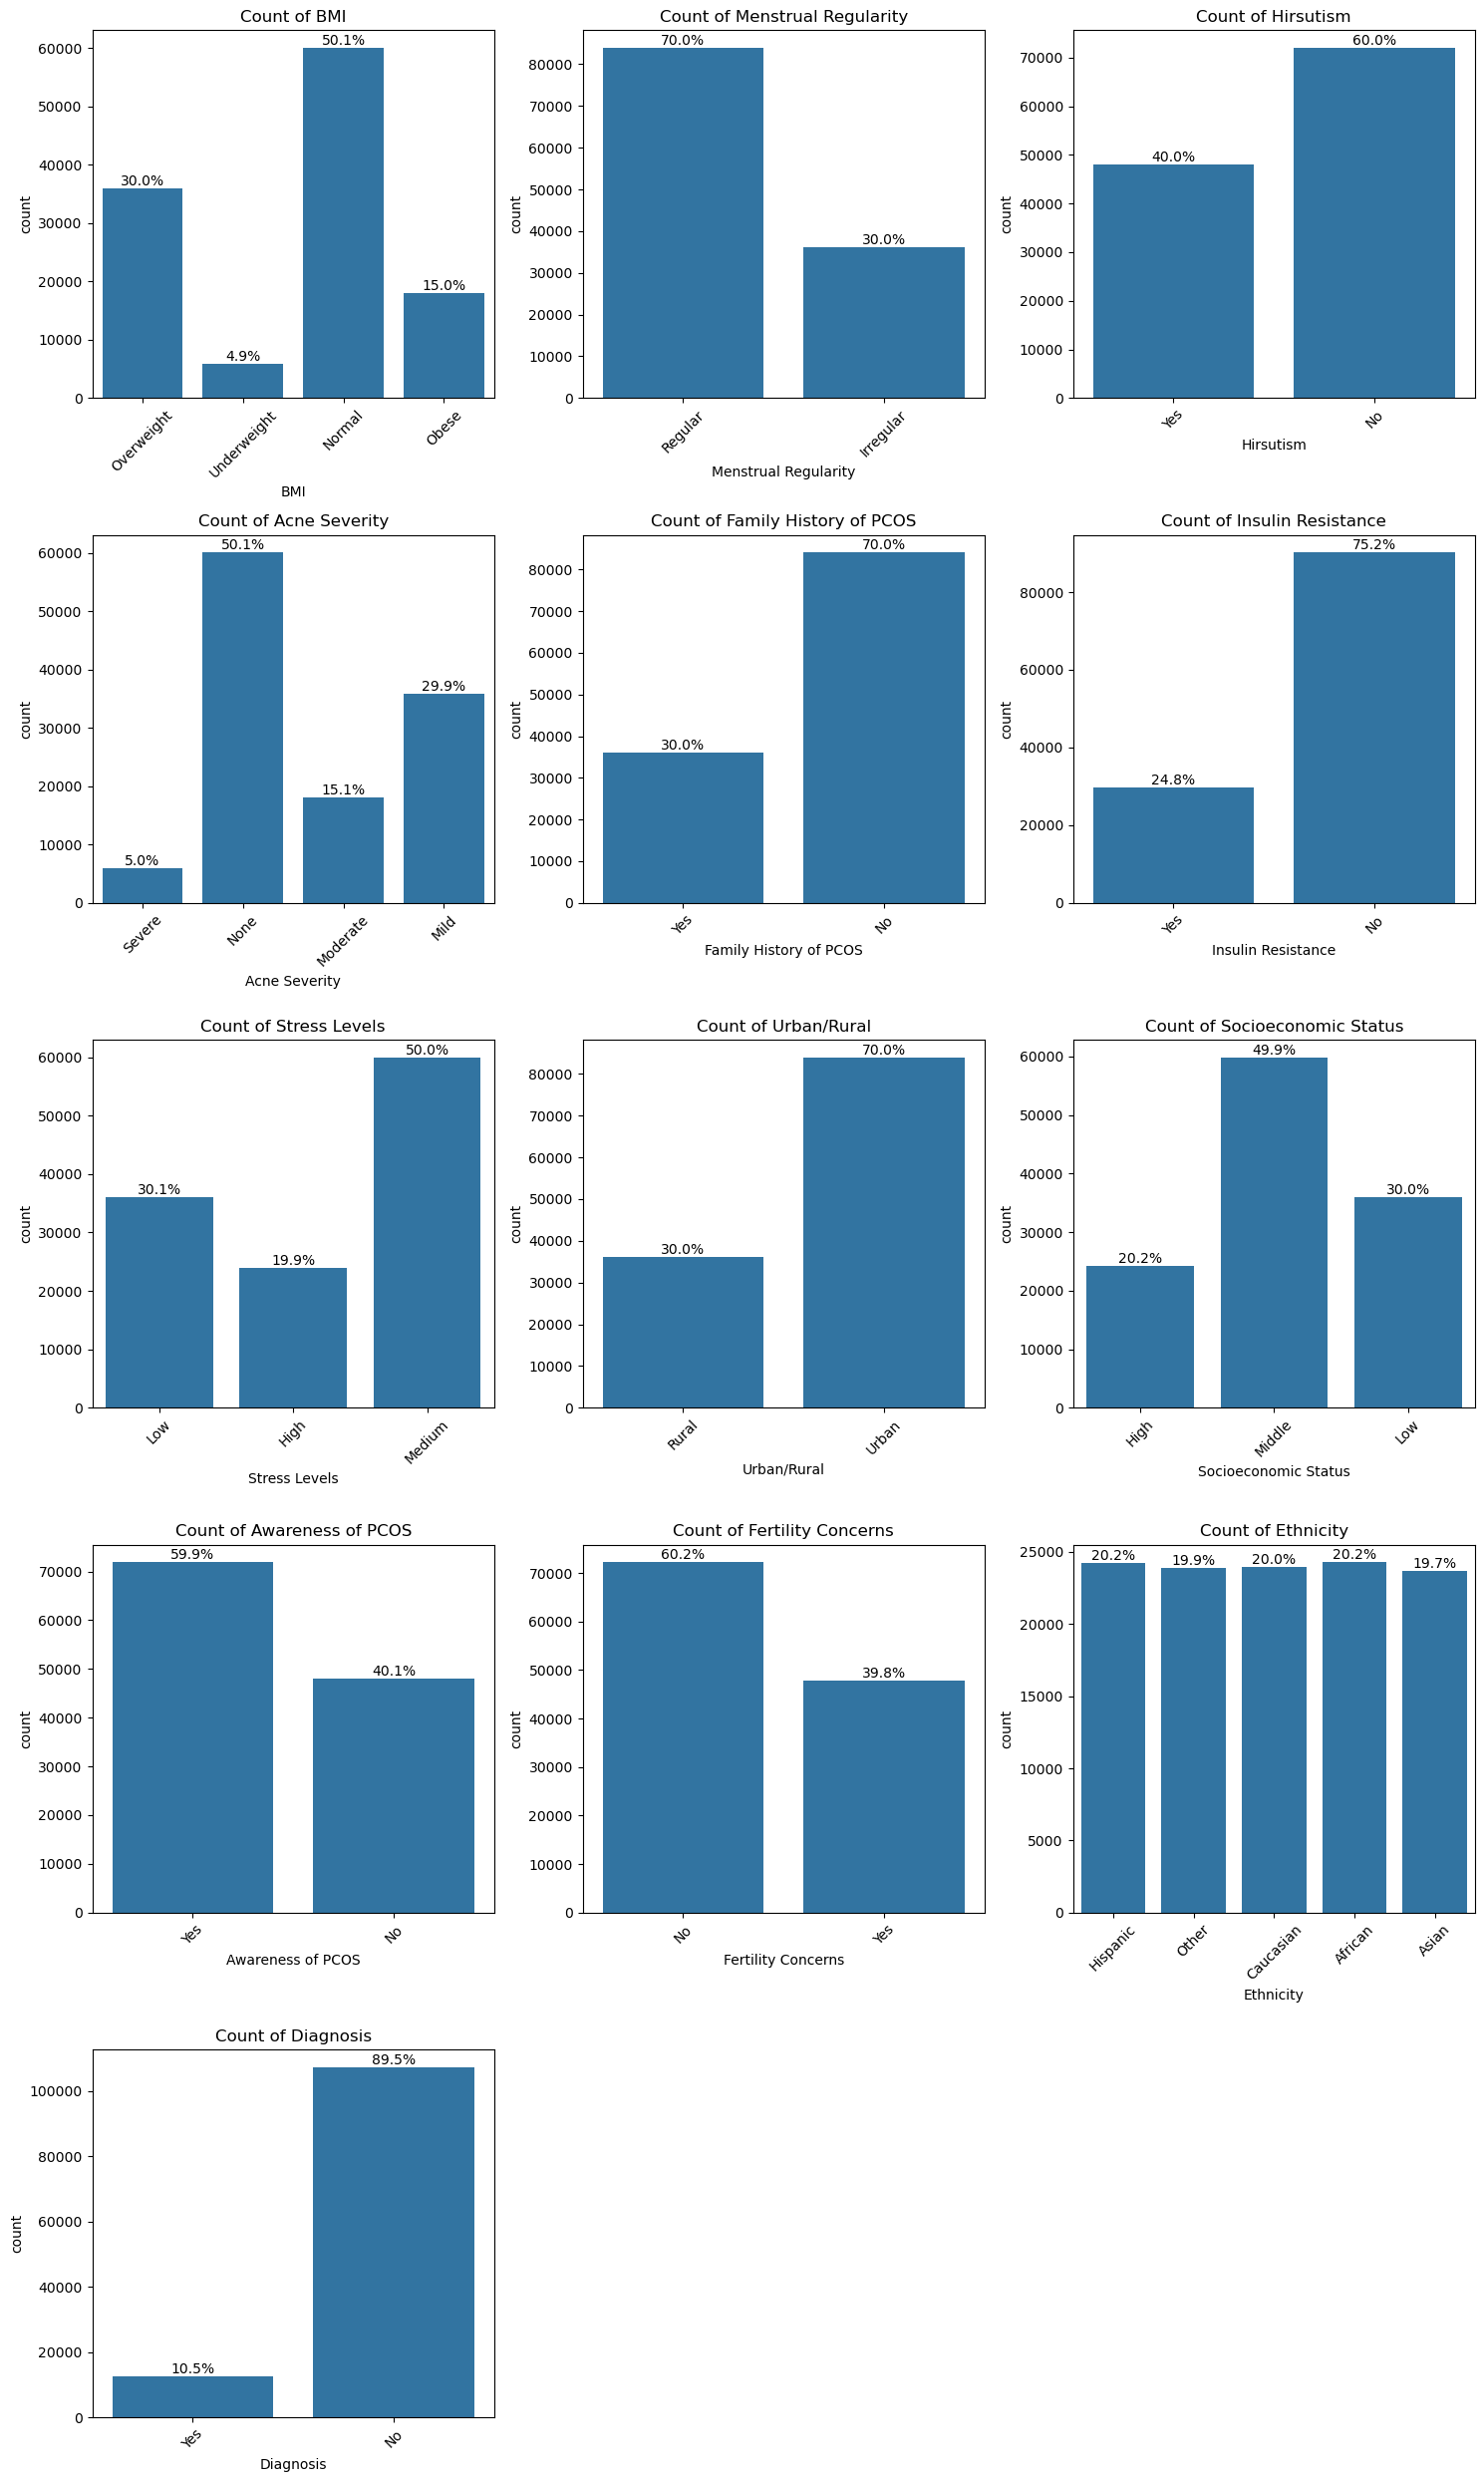

In [27]:
plot_categorical_variables(df, exclude_column='Country')

##### Bivariate Analysis

In [29]:
# Function to show stacked barplots of categorical variables against target
def plot_stacked_bar(data, target_variable, exclude_column=None):
    # Identify categorical columns excluding the target variable
    categorical_cols = data.select_dtypes(include=['object', 'category']).columns
    categorical_cols = categorical_cols.drop(target_variable, errors='ignore')

    # Remove the excluded column if specified
    if exclude_column in categorical_cols:
        categorical_cols = categorical_cols.drop(exclude_column)
    
    # Set up the matplotlib figure
    num_vars = len(categorical_cols)
    fig, axes = plt.subplots(nrows=(num_vars // 3) + 1, ncols=3, figsize=(15, 5 * ((num_vars // 3) + 1)))
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    for i, col in enumerate(categorical_cols):
        # Create a DataFrame for the counts of each category in relation to the target variable
        count_data = data.groupby([col, target_variable]).size().unstack(fill_value=0)
        
        # Calculate percentages
        percentage_data = count_data.div(count_data.sum(axis=1), axis=0) * 100
        
        # Plot stacked bar plot
        percentage_data.plot(kind='bar', stacked=True, ax=axes[i], color=sns.color_palette("pastel"))
        
        # Set titles and labels
        axes[i].set_title(f'Stacked Bar Plot of {col} vs {target_variable}')
        axes[i].set_ylabel('Percentage')
        axes[i].set_xlabel(col)
        axes[i].legend(title=target_variable, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

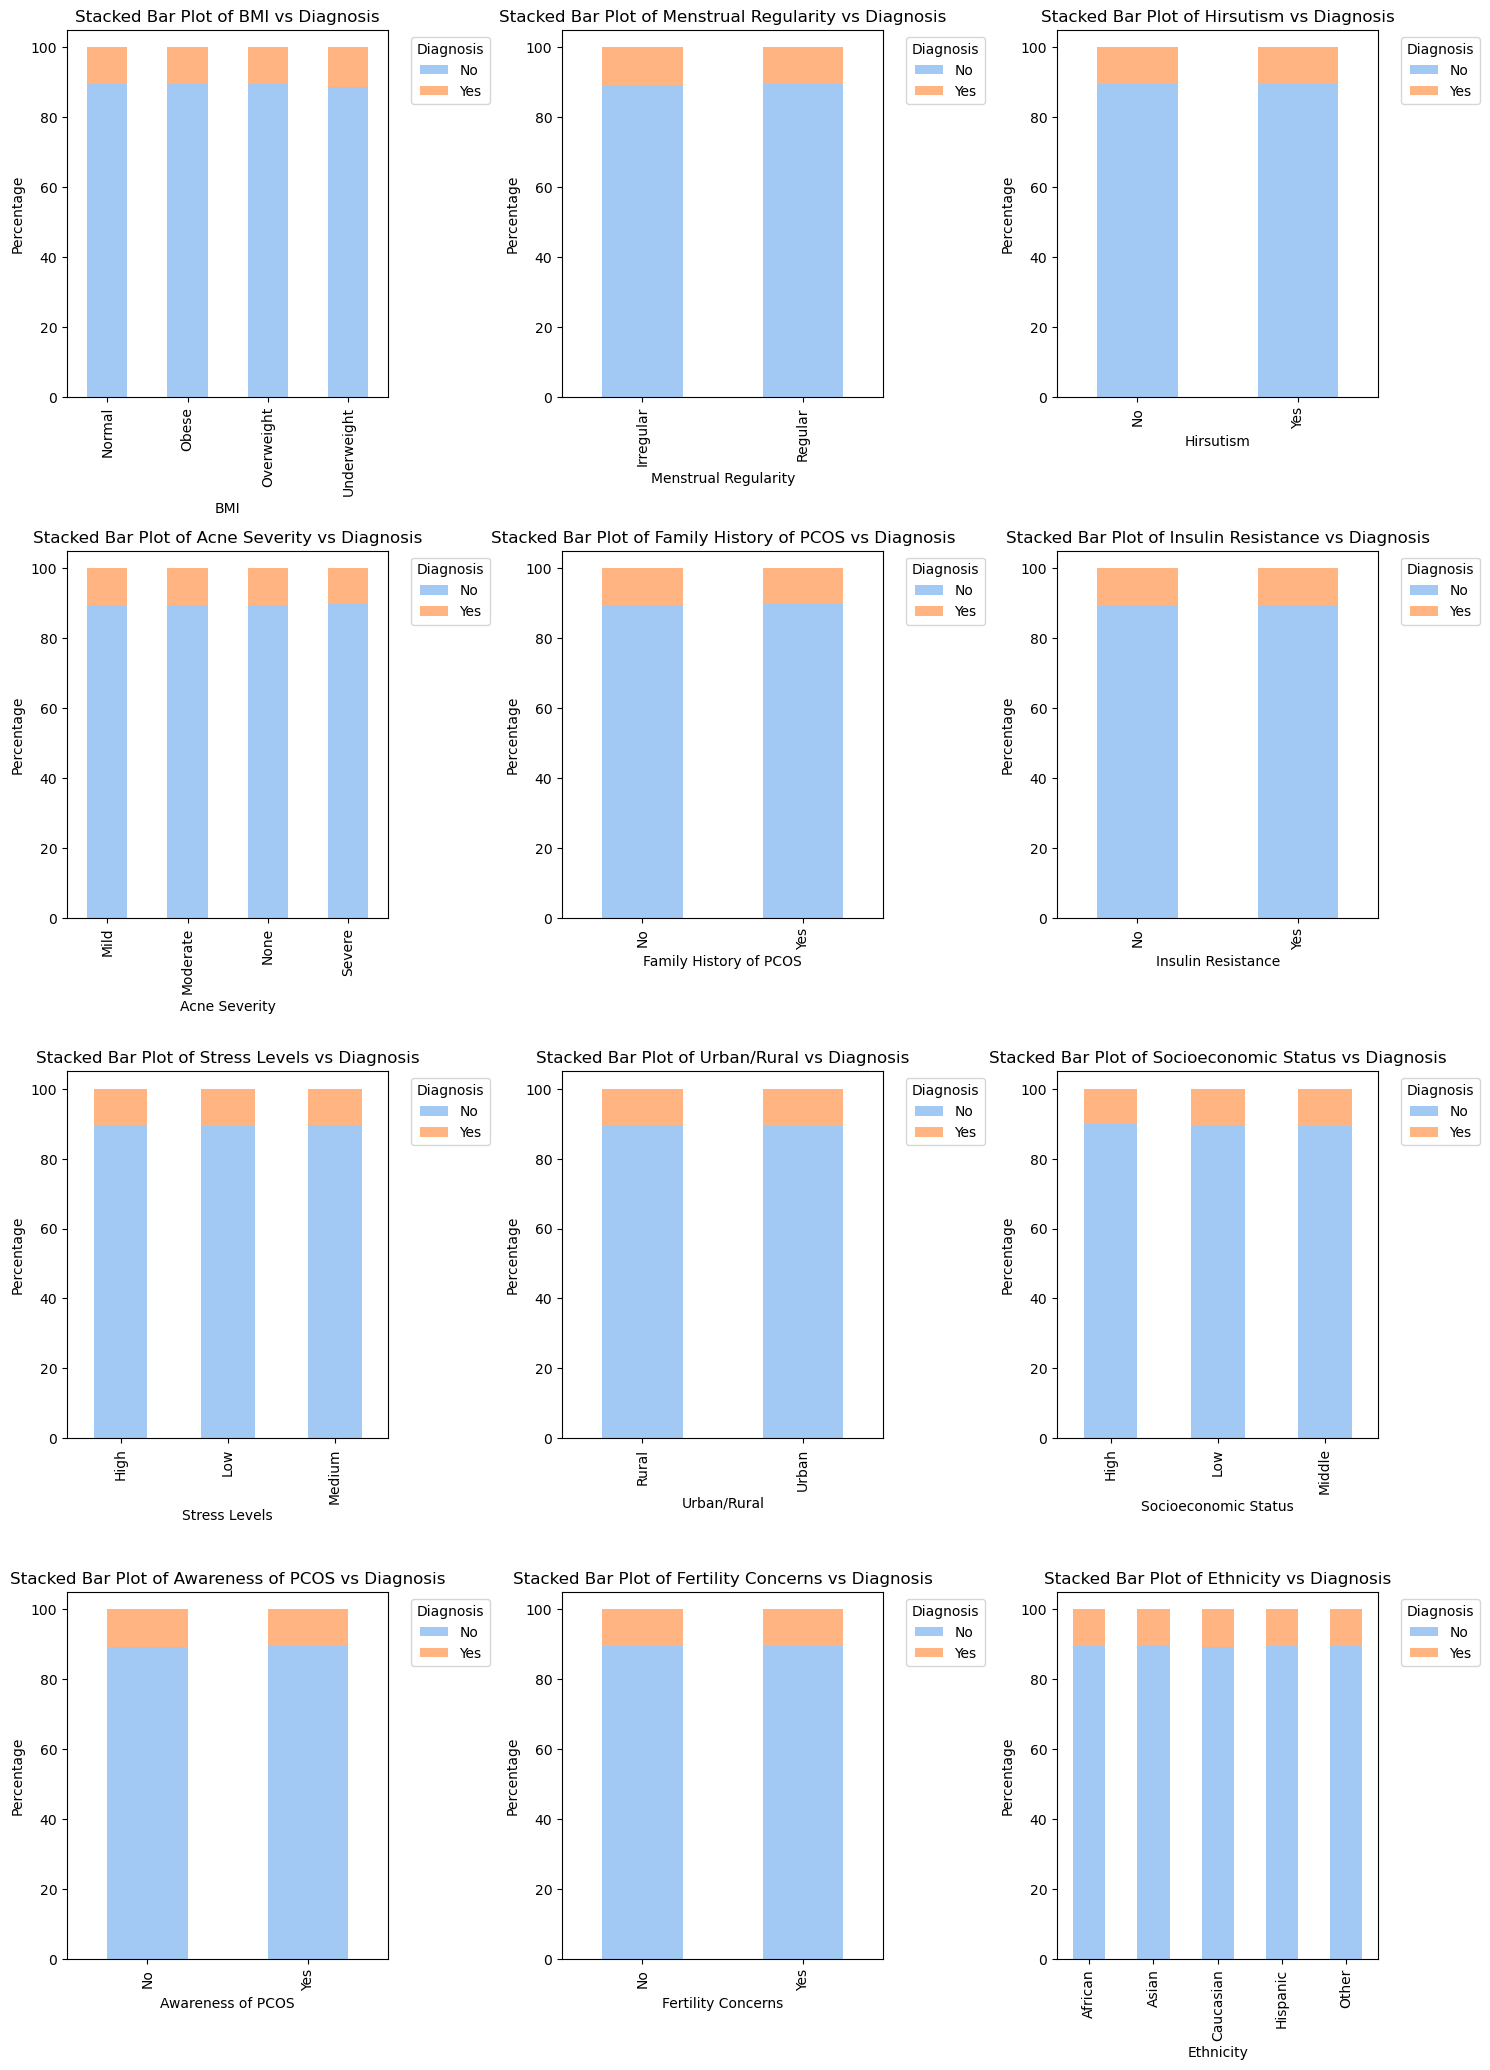

In [30]:
plot_stacked_bar(df, target_variable='Diagnosis', exclude_column='Country')

In [31]:
# Change column names: replace spaces with underscores and convert to lowercase
df.columns = df.columns.str.replace(' ', '_').str.lower()

# Display the updated DataFrame
df.head()

,country,age,bmi,menstrual_regularity,hirsutism,acne_severity,family_history_of_pcos,insulin_resistance,lifestyle_score,stress_levels,urban/rural,socioeconomic_status,awareness_of_pcos,fertility_concerns,undiagnosed_pcos_likelihood,ethnicity,diagnosis
0,Madagascar,26,Overweight,Regular,Yes,Severe,Yes,Yes,2,Low,Rural,High,Yes,No,0.107938,Hispanic,Yes
1,Vietnam,16,Underweight,Regular,Yes,None,No,Yes,4,High,Rural,Middle,Yes,No,0.156729,Other,No
2,Somalia,41,Normal,Regular,No,Moderate,No,No,7,Medium,Urban,Middle,Yes,Yes,0.202901,Other,No
3,Malawi,27,Normal,Irregular,No,Mild,No,No,10,Low,Urban,High,Yes,No,0.073926,Caucasian,Yes
4,France,26,Overweight,Irregular,Yes,None,No,No,7,Medium,Urban,Middle,No,No,0.229266,Caucasian,No


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   country                      120000 non-null  object 
 1   age                          120000 non-null  int64  
 2   bmi                          120000 non-null  object 
 3   menstrual_regularity         120000 non-null  object 
 4   hirsutism                    120000 non-null  object 
 5   acne_severity                120000 non-null  object 
 6   family_history_of_pcos       120000 non-null  object 
 7   insulin_resistance           120000 non-null  object 
 8   lifestyle_score              120000 non-null  int64  
 9   stress_levels                120000 non-null  object 
 10  urban/rural                  120000 non-null  object 
 11  socioeconomic_status         120000 non-null  object 
 12  awareness_of_pcos            120000 non-null  object 
 13 

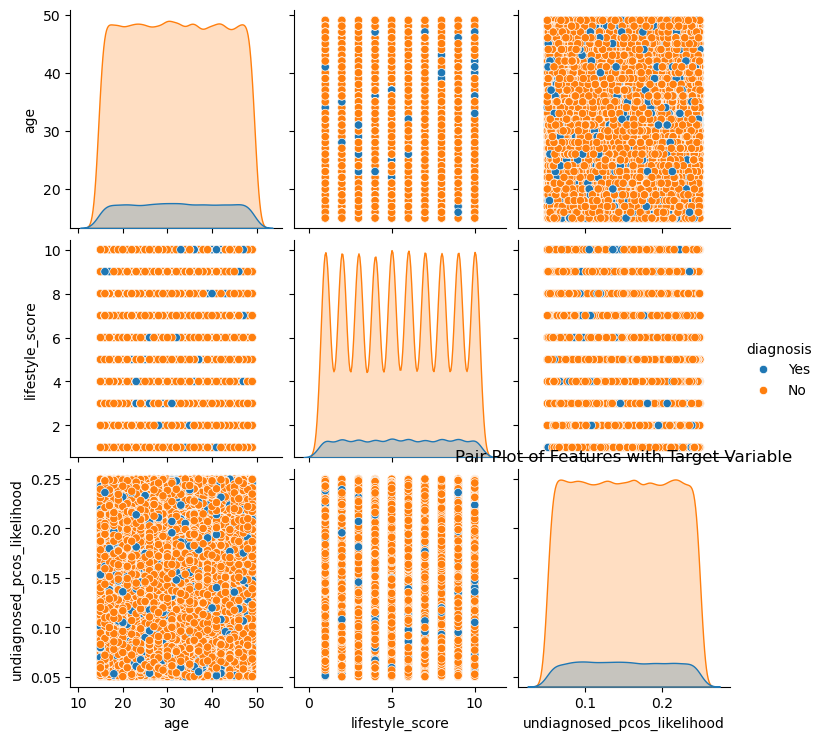

In [33]:
# Create a pair plot
sns.pairplot(df, hue='diagnosis')
plt.title('Pair Plot of Features with Target Variable')
plt.show()

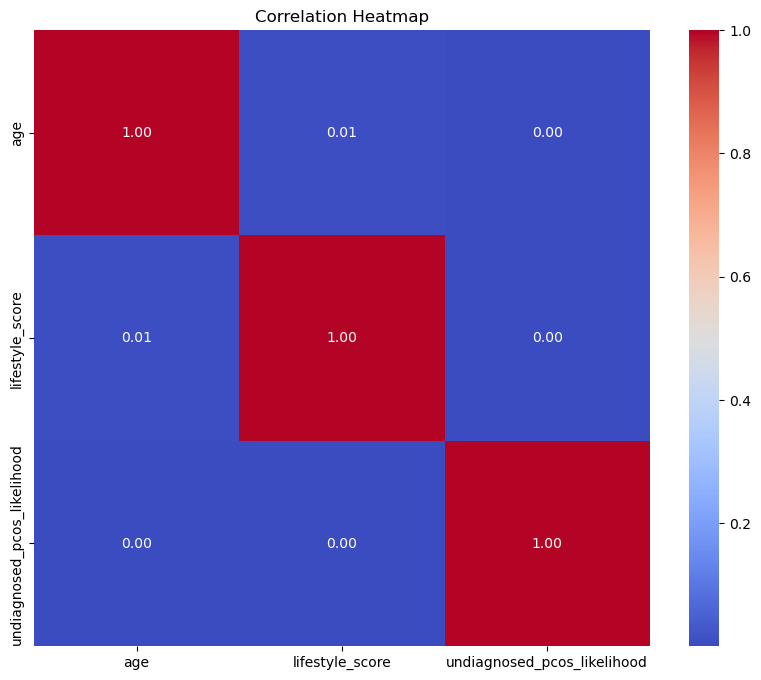

In [34]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.show()

In [35]:
df_labelled = df.copy()

        country  age  bmi  menstrual_regularity  hirsutism  acne_severity  \
0            34   26    2                     1          1              3   
1            73   16    3                     1          1              2   
2            56   41    0                     1          0              1   
3            35   27    0                     0          0              0   
4            20   26    2                     0          1              2   
...         ...  ...  ...                   ...        ...            ...   
119995       24   28    0                     1          0              1   
119996       40   35    2                     1          0              2   
119997       10   16    0                     1          0              1   
119998        6   15    1                     1          1              2   
119999        7   17    1                     0          1              2   

        family_history_of_pcos  insulin_resistance  lifestyle_score  \
0   

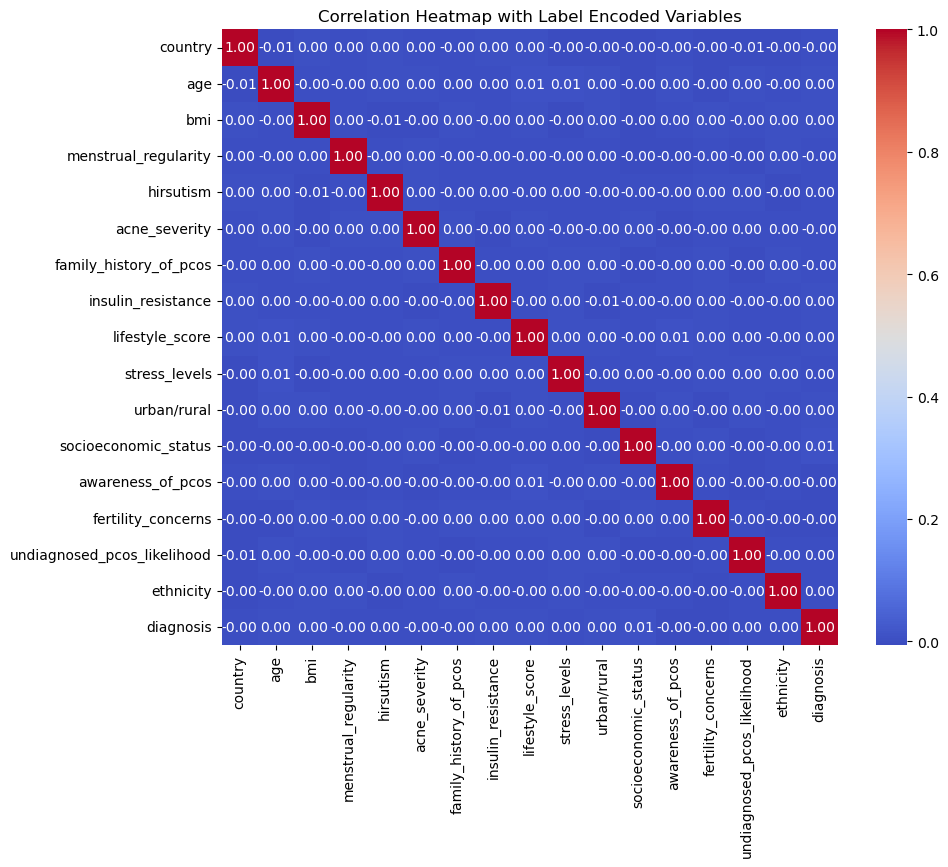

In [36]:
# Identify categorical columns
categorical_cols = df_labelled.select_dtypes(include=['object']).columns

# Initialize LabelEncoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to each categorical column
for col in categorical_cols:
    df_labelled[col] = label_encoder.fit_transform(df_labelled[col])

# Display the updated DataFrame
print(df_labelled)

# Calculate the correlation matrix
correlation_matrix = df_labelled.corr()

# Create a heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap with Label Encoded Variables')
plt.show()

In [37]:
df_labelled.head()

,country,age,bmi,menstrual_regularity,hirsutism,acne_severity,family_history_of_pcos,insulin_resistance,lifestyle_score,stress_levels,urban/rural,socioeconomic_status,awareness_of_pcos,fertility_concerns,undiagnosed_pcos_likelihood,ethnicity,diagnosis
0,34,26,2,1,1,3,1,1,2,1,0,0,1,0,0.107938,3,1
1,73,16,3,1,1,2,0,1,4,0,0,2,1,0,0.156729,4,0
2,56,41,0,1,0,1,0,0,7,2,1,2,1,1,0.202901,4,0
3,35,27,0,0,0,0,0,0,10,1,1,0,1,0,0.073926,2,1
4,20,26,2,0,1,2,0,0,7,2,1,2,0,0,0.229266,2,0


In [38]:
# Drop specific irrelevant columns
df_labelled.drop(columns=['country', 'urban/rural'], inplace=True)


In [39]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load your dataset
data = df_labelled.copy()
X = data.drop('diagnosis', axis=1)  # Features
y = data['diagnosis']  # Target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Train a model
model = RandomForestClassifier()
model.fit(X_resampled, y_resampled)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87     32209
           1       0.11      0.15      0.13      3791

    accuracy                           0.78     36000
   macro avg       0.50      0.50      0.50     36000
weighted avg       0.81      0.78      0.80     36000



In [40]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, f_classif

# Load dataset
data = df_labelled.copy()
X = data.drop('diagnosis', axis=1)  # Features
y = data['diagnosis']  # Target variable

# Apply SelectKBest
selector = SelectKBest(score_func=f_classif, k=5)  # Select the top 10 features
X_selected = selector.fit_transform(X, y)

print("Original shape:", X.shape)
print("Reduced shape:", X_selected.shape)

Original shape: (120000, 14)
Reduced shape: (120000, 5)


In [41]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Train a model
model = RandomForestClassifier()
model.fit(X_resampled, y_resampled)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87     21457
           1       0.11      0.15      0.13      2543

    accuracy                           0.78     24000
   macro avg       0.50      0.50      0.50     24000
weighted avg       0.81      0.78      0.79     24000



In [77]:
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    # Update "estimator" instead of "base_estimator"
    "estimator": [
        DecisionTreeClassifier(max_depth=1, class_weight="balanced", random_state=1),
        DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=1),
    ],
    "n_estimators": np.arange(80, 101, 10),
    "learning_rate": np.arange(0.1, 0.4, 0.1),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator=abc_tuned, param_grid=parameters, cv=5, scoring=acc_scorer, n_jobs=-1)
grid_obj = grid_obj.fit(X_resampled, y_resampled)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_resampled, y_resampled)



AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=2,
                                                    random_state=1),
                   learning_rate=0.30000000000000004, n_estimators=100,
                   random_state=1)

In [ ]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [200, 250],
    "subsample": [0.9, 1],
    "max_features": [0.8, 0.9],
    "learning_rate": np.arange(0.1, 0.21, 0.1),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator=gbc_tuned, param_grid=parameters, cv=5, scoring=acc_scorer, n_jobs=1)
grid_obj = grid_obj.fit(X_resampled, y_resampled)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_resampled, y_resampled)

In [ ]:
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True, class_weight='balanced')

parameters = {
    "max_depth": list(np.arange(5, 15, 5)),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [5, 7],
    "n_estimators": np.arange(15, 26, 5),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator = rf_tuned, param_grid=parameters, scoring=acc_scorer, cv = 5, n_jobs = -1)
grid_obj = grid_obj.fit(X_resampled, y_resampled)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_resampled, y_resampled)

In [ ]:
from sklearn.ensemble import StackingClassifier
estimators = [
    ("AdaBoost", abc_tuned),
    ("Gradient Boosting", gbc_tuned),
    ('RandomForestClassifier', rf_tuned),
]
final_estimator = xgb_tuned
stacking_classifier = StackingClassifier(estimators = estimators, final_estimator=final_estimator, cv=5)
stacking_classifier.fit(X_resampled, y_resampled)